# In-Class Assignment: Overfitting in Machine Learning & Review of CMSE 202
# Day 24
# CMSE 202

In todays class we'll take a moment to look back on everything we've covered this semester and, in groups and as a class, we'll try to build a concept map of CMSE 202 (much like we did at the beginning of the semester to remind ourselves what was covered in 201!).

### <p style="text-align: right;"> &#9989; **Put your name here** </p>
#### <p style="text-align: right;"> &#9989; Put your group member names here</p>

### Agenda for today's class

</p>

1. [Review of bias, variance, and overfitting (and underfitting) concepts](#biasvariance-1)
1. [Small group discussion and review: key themes and main points](#smallgroup-1)
1. [Classroom wide discussion of the key themes and main points](#wholeclass-1)
1. [Small group activity: building the map](#smallgroup-2)
1. [Diving Deeper](#divingDeeper)

------
<a id="biasvariance-1"></a>

## 1. Bias vs Variance and Overfitting vs Underfitting

The bias–variance tradeoff describes how model complexity affects two different sources of prediction error: **bias** and **variance**.  

<img src="https://raw.githubusercontent.com/msu-cmse-courses/cmse202-supplemental-data/refs/heads/main/images/bias_vs_variance.png" alt="bias variance examples" width="500" align="center"/>




**Learning Curves**

The following figure was presented in the pre-class assignment. It shows learning curves for three different models (A, B, and C) trained on the same data. The training loss and validation loss are plotted as a function of the number of training examples.  Reminder that loss is the error of the model, so lower is better. Also, remember that the training loss is the error on the data that the model was trained on, while the validation loss is the error on a separate set of data that was not used for training.

<img src="https://raw.githubusercontent.com/msu-cmse-courses/cmse202-supplemental-data/refs/heads/main/images/learn_curve_examples.png" alt="learning curve examples" width="800"/>

&#9989; **Question 1.1**:  For each model, describe whether it is underfitting, overfitting, or just right. Justify your answer based on the learning curves. 

Model A: underfitting because both training loss and validation loss are still fairly high, and the model has not fit the data very well yet.

Model B: just right because both training and validation loss decrease and level off with a relatively small gap between them.

Model C: overfitting because training loss keeps decreasing, but validation loss starts increasing after a point.

### Example of learning curves for a binary classification problem

We will use the UCI Default of Credit Card Clients dataset for this example. This dataset contains information about credit card clients and whether they defaulted on their payments. We will train a simple Multi-layer Perceptron (MLP) classifier on this data and plot the learning curves to see how the training and validation loss evolve over epochs. Additional details about the dataset can be found here: https://www.kaggle.com/datasets/uciml/default-of-credit-card-clients-dataset

> Reference for data:
> Lichman, M. (2013). UCI Machine Learning Repository [http://archive.ics.uci.edu/ml]. Irvine, CA: University of California, School of Information and Computer Science.
> 
You can download the dataset from here:

`https://raw.githubusercontent.com/msu-cmse-courses/cmse202-supplemental-data/refs/heads/main/data/UCI_Credit_Card_15k.csv`

The MLP is constructed from multiple layers of perceptrons, which are the basic building blocks of neural networks. Each perceptron takes a weighted sum of its inputs and applies an activation function to produce an output. By stacking multiple layers of perceptrons, the MLP can learn hierarchical representations of the data, allowing it to capture complex relationships between features and the target variable.

&#9989; **1.2 To Do:** Read the following code and try to understand how the learning curves are generated. Run this code and then answer the questions about the learning curves that follow.




In [5]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix

# 1. Load data
df = pd.read_csv("UCI_Credit_Card_15k.csv")

# 2. Features and target
# Drop ID; use all other columns except the target as features
X = df.drop(columns=["ID", "default.payment.next.month"]).values
y = df["default.payment.next.month"].values  # 1 = default, 0 = no default

# 3. Train/validation split 
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=0)

# 4. Scale features to have mean=0 and std=1 (important for perceptron/SGD)
# This is a common preprocessing step for many ML algorithms, especially those that use gradient-based optimization
# This ensures that all features are on the same scale, which can help with convergence and performance

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)

# 5. Define MLP, Multi-layer Perceptron classifier with 2 hidden layers (48 and 16 neurons)
# Clear mlp from previous runs (if any) to avoid issues with warm_start
mlp = None
mlp = MLPClassifier(
    hidden_layer_sizes=(48, 16),  # simple 2-layer MLP
    activation="relu",
    solver="sgd",
    learning_rate_init=0.1,
    batch_size=256,
    max_iter=1,        # one epoch per partial_fit call
    warm_start=True,   # Each call to fit will continue training from the previous state
    shuffle=True,
    random_state=0
)

# 6. Loop to train MLP for multiple epochs and record losses
# Note: MLP in sklearn does not have a built-in way to get loss per epoch,
# so we will fit it for upto 100 epoch, one fit at a time, and evaluate after each iteration/epoch

n_epochs = 100
train_loss_list = []
val_loss_list = []

for epoch in range(n_epochs):
    if np.mod(epoch, 10) == 0:
        print(f"Epoch {epoch}/{n_epochs}")

    if epoch == 0:
        mlp.partial_fit(X_train, y_train, classes=np.array([0, 1]))  # initial fit to set up classes
    else:
        mlp.partial_fit(X_train, y_train)

    # Predictions after this epoch
    y_train_pred = mlp.predict(X_train)
    y_val_pred  = mlp.predict(X_val)

    # 0-1 loss = fraction misclassified
    train_loss = 1 - (y_train_pred == y_train).mean()  # 1 - accuracy
    train_loss_list.append(train_loss)

    val_loss  = 1 - (y_val_pred == y_val).mean()
    val_loss_list.append(val_loss)

print("Final Training Loss:", train_loss_list[-1])
print("Final Validation Loss:", val_loss_list[-1])

print("------------------------")
print("Final Training Accuracy:", 1 - train_loss_list[-1])
print("Final Validation Accuracy:", 1 - val_loss_list[-1])

Epoch 0/100
Epoch 10/100
Epoch 20/100
Epoch 30/100
Epoch 40/100
Epoch 50/100
Epoch 60/100
Epoch 70/100
Epoch 80/100
Epoch 90/100
Final Training Loss: 0.14933333333333332
Final Validation Loss: 0.19433333333333336
------------------------
Final Training Accuracy: 0.8506666666666667
Final Validation Accuracy: 0.8056666666666666


&#9989; **1.3 Do This**:  In the cell below, plot the learning curves generated above for the MLP classifier on the credit card dataset. Is this model overfitting, underfitting, or just right. Justify your answer based on the shape of the learning curves.

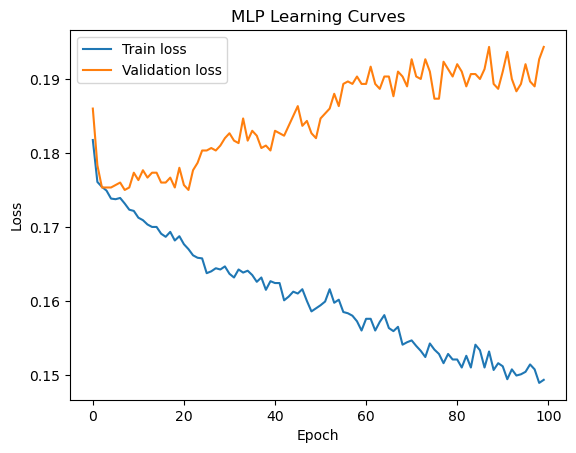

In [7]:
import matplotlib.pyplot as plt

plt.plot(train_loss_list, label="Train loss")
plt.plot(val_loss_list, label="Validation loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("MLP Learning Curves")
plt.legend()
plt.show()

&#9989; **1.4 Do This**:  Change one thing about the model (e.g. add more layers, change the learning rate, etc.) to make the learning curves "better" behaved (to reduce overfitting or underfitting concerns).  Then, re-run the code to generate new learning curves. How did the learning curves change? Is the new model overfitting, underfitting, or just right? Justify your answer based on the shape of the new learning curves.

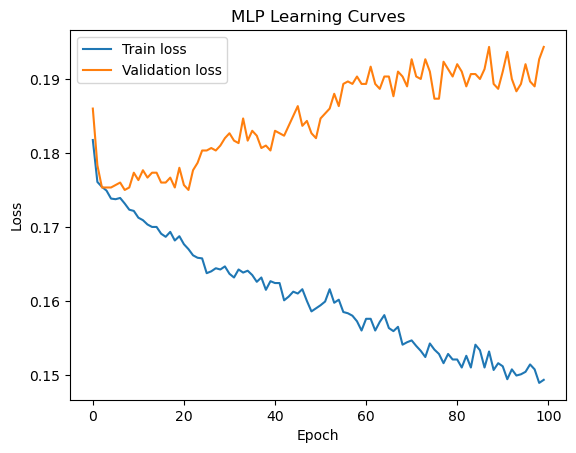

In [11]:
# Put your answer here or change the code above 
learning_rate_init=0.01
import matplotlib.pyplot as plt

plt.plot(train_loss_list, label="Train loss")
plt.plot(val_loss_list, label="Validation loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("MLP Learning Curves")
plt.legend()
plt.show()

---
### &#128721; Check for understanding:
Check in with your group members to make sure you understand the concepts of bias, variance, overfitting, and underfitting. Do you have any questions about these concepts that you want to discuss with the class?

Once you've discussed with your group, we'll have a classroom wide discussion about these concepts and any questions you have about them and will then continue on to the next part of the class where we will review the key themes and main points from the semester.

---
<a id="smallgroup-1"></a>
## 2. Small group discussion and review: key themes and main points

In your pre-class assignment, you were asked to identify the key themes and main points you took away from this class over the course of the semester. You should have been able to justify your choices based on the collection of assignments you've completed (PCAs, ICAs, homework assignments).

&#9989; **Do This:** In your groups, each person should take a moment to share what you identified as the key themes or main points for the course. As much as you can, offer examples from class to justify your choices. Once everyone has shared, **condense your list of possible key themes or main points in a list of 3-4. Appoint someone in your group who will be willing to share these with the whole class.** 

You will have **~10 minutes** to complete this task.

Record the themes/point you come up with in the cell below.

<font size=+3>&#9998;</font> Do This - Erase the contents of this cell and replace it with the key themes/points your group came up with (double-click on this text to edit this cell, and hit shift+enter to save the text)

---
<a id="wholeclass-1"></a>
## 2. Classroom wide discussion of the key themes and main points

As a class, we will hear from each group about what they identified as 3-4 key themes or main points.

**We'll look for overlap and differences and, as a class, try to come up with a final list of themes.**

We'll use this as the starting point for our concept map of CMSE 202 and we'll build it out using collaborative whiteboards.

Model evaluation and generalization were major themes of the course. We repeatedly looked at training performance versus testing or validation performance to decide whether a model actually learned useful patterns.
Bias, variance, underfitting, and overfitting were central ideas. Many assignments focused on understanding when a model is too simple, too complex, or balanced appropriately.
Using data science tools to build and test models was another major theme. We used Python, pandas, NumPy, scikit-learn, and plotting tools to clean data, train models, and interpret results.
Comparing different machine learning methods was also important. Across the course we worked with linear regression, logistic regression, symbolic regression, and neural networks, which showed how different models are useful for different kinds of problems.

----
<a id="smallgroup-1"></a>
## 3. Small group activity: building the map

Now that we have a list of main themes, we're going to go one level deeper.

&#9989; **Do This:** In your small group, discuss the related points, additional topics, and things we've done in class or on out-of-class assignments that are tied to the main themes. Add these to the collaborative whiteboard. In addition, as the whiteboard is populated, look for connections between the themes and the notes. **Draw these connections on the whiteboard**. 

Again, you will have **~10 minutes** to complete this task.


---
<a id="divingDeeper"></a>
## 4. Diving Deeper

How do we feel about the concept map we've built? Are there specific concepts you don't feel comfortable with or would like additional discussion prior to the exam. 

**Work with your group to discuss any concepts that are challenging. As well, check in with the instructional team with your questions so we can discuss these topics so you can leave the class today feeling confident, both for the exam and in leaving CMSE 202 with new computational modeling skills!**

-----
### Congratulations, we're done!

Now, you just need to submit this assignment by uploading it to the course <a href="https://d2l.msu.edu/">Desire2Learn</a> web page for today's submission folder (Don't forget to add your names in the first cell).


&#169; Copyright 2026, The Department of Computational Mathematics, Science and Engineering at Michigan State University